In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import tensorflow_hub as hub


#Getting data ready (turning images into tensors)

In [3]:
import pandas as pd
labels_csv = pd.read_csv("/Users/lukeopany/Desktop/dog-vision/labels.csv")
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


<Axes: xlabel='breed'>

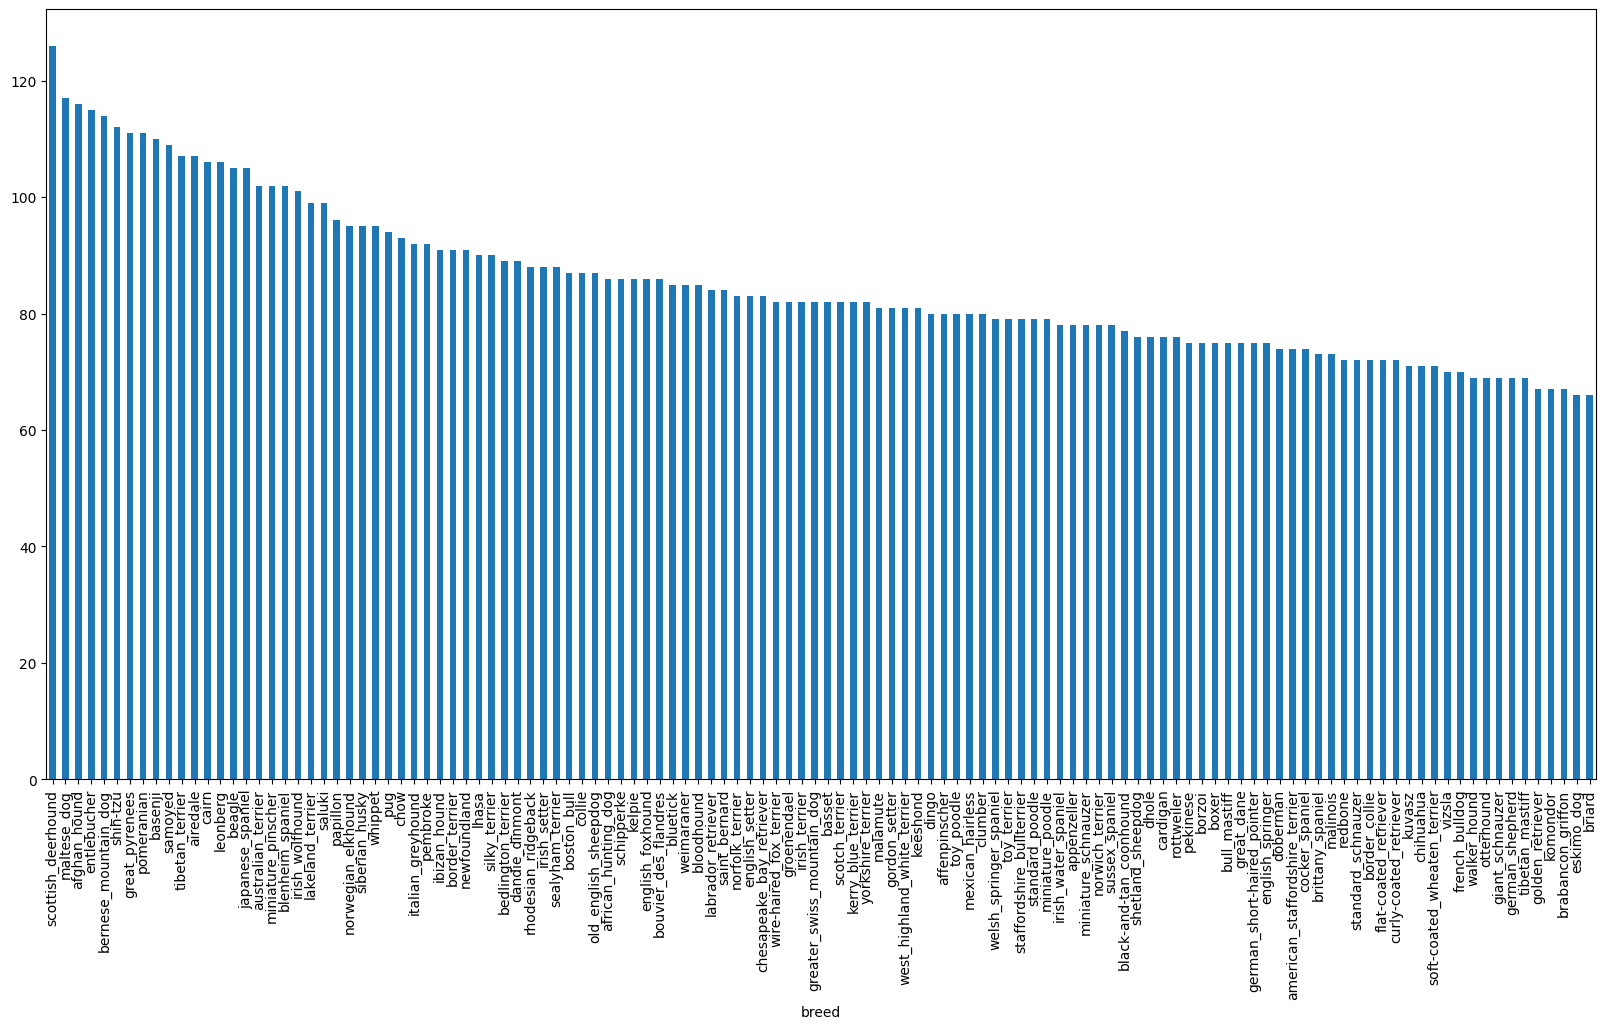

In [4]:
#Find out how many dog breeds are there for each class and plot
labels_csv["breed"].value_counts().plot.bar(figsize=(20,10))

In [5]:
print(labels_csv["breed"].value_counts().mean())

85.18333333333334


In [6]:
#Viewing an image inside the notebook -- copy the image file path and include image id

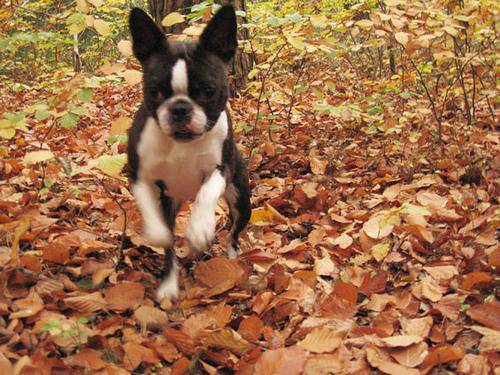

In [7]:
from IPython.display import Image
Image("/Users/lukeopany/Desktop/dog-vision/train/000bec180eb18c7604dcecc8fe0dba07.jpg")

Because it would take a lot of time to type out the filepath each time we need to get an image, we are going to create a pathname from image IDs

In [8]:
#Create pathname from image ID's
filename = "/Users/lukeopany/Desktop/dog-vision/train/" + labels_csv["id"] + ".jpg"
# Avoid printing the full Series (can freeze the notebook output)
filename.head()

0    /Users/lukeopany/Desktop/dog-vision/train/000b...
1    /Users/lukeopany/Desktop/dog-vision/train/0015...
2    /Users/lukeopany/Desktop/dog-vision/train/001c...
3    /Users/lukeopany/Desktop/dog-vision/train/0021...
4    /Users/lukeopany/Desktop/dog-vision/train/0021...
Name: id, dtype: str

In [9]:
#Check whether the number of filenames matches the number of actual images

In [10]:
import os

# Get the list of all files in the training directory
train_path = "/Users/lukeopany/Desktop/dog-vision/train/"
files = os.listdir(train_path)

# Compare the lengths
print(f"Number of filenames generated: {len(filename)}")
print(f"Number of actual images in folder: {len(files)}")

if len(filename) == len(files):
    print("Success: The number of filenames matches the number of actual images.")
else:
    print("Warning: The number of filenames does not match the number of actual images.")

Number of filenames generated: 10222
Number of actual images in folder: 10222
Success: The number of filenames matches the number of actual images.


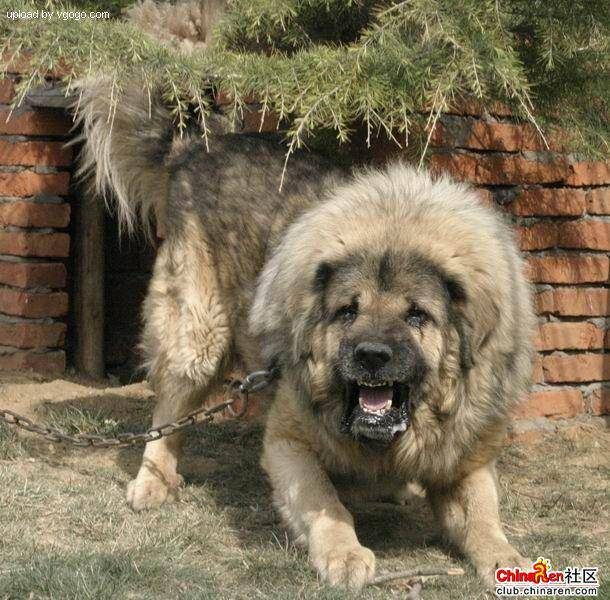

In [11]:
#One more check
from IPython.display import Image
Image(filename[9000])

In [12]:
labels_csv['breed'][9000]

'tibetan_mastiff'

Since we've now got our training image filepath in a list, let's prepare our lables

In [13]:
import numpy as np
labels = labels_csv['breed']
labels = np.array(labels)
len(labels)

10222

In [14]:
#compare the number of labels to the number in files

In [15]:
# Compare the number of labels to the number of actual images in the folder
print(f"Number of labels: {len(labels)}")
print(f"Number of actual images in folder: {len(files)}")

if len(labels) == len(files):
    print("Success: The number of labels matches the number of actual images.")
else:
    print("Warning: There is a mismatch between the number of labels and image files.")

Number of labels: 10222
Number of actual images in folder: 10222
Success: The number of labels matches the number of actual images.


In [16]:
# Find the unique value labels
unique_breeds = np.unique(labels)
len(unique_breeds)

120

In [17]:
# Turn a single label into an array of booleans
labels[0] == unique_breeds

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [18]:
# Turn every label into an array of booleans
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [19]:
len(boolean_labels)

10222

In [20]:
# Example: Turning a boolean array into integers
print(labels[0]) # Original labels
print(np.where(unique_breeds == labels[0])) #index where label occurs
print(boolean_labels[0].argmax()) # index where label occurs in boolean array
print(boolean_labels[0].astype(int)) # There will be a 1 where the sample occurs



boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [21]:
print(labels[2])
print(boolean_labels[2].astype(int))


pekinese
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [22]:
filename[:10]

0    /Users/lukeopany/Desktop/dog-vision/train/000b...
1    /Users/lukeopany/Desktop/dog-vision/train/0015...
2    /Users/lukeopany/Desktop/dog-vision/train/001c...
3    /Users/lukeopany/Desktop/dog-vision/train/0021...
4    /Users/lukeopany/Desktop/dog-vision/train/0021...
5    /Users/lukeopany/Desktop/dog-vision/train/0022...
6    /Users/lukeopany/Desktop/dog-vision/train/0029...
7    /Users/lukeopany/Desktop/dog-vision/train/002a...
8    /Users/lukeopany/Desktop/dog-vision/train/003d...
9    /Users/lukeopany/Desktop/dog-vision/train/0042...
Name: id, dtype: str

This whole process has been trying to get our data into an accesible format

Creating our own validation set

In [23]:
#This can be achieved by creating the X and y variable (normally for test-train split but can be used in our case to split the data into train - val)

In [24]:
x = filename
y = boolean_labels

In [25]:
len(x), len(y)

(10222, 10222)

In [26]:
#To save time, start with ~1000 samples 

In [27]:
# Set the number of images to use for experimenting
NUM_IMAGES = 1000
# Split into train and validation sets (80/20 split)
NUM_TRAIN = int(NUM_IMAGES * 0.8)  # 800 images for training -- int ensures no float(decimals)

x_train = x[:NUM_TRAIN]
y_train = y[:NUM_TRAIN]

x_val = x[NUM_TRAIN:NUM_IMAGES]
y_val = y[NUM_TRAIN:NUM_IMAGES]

print(f"Training samples:   {len(x_train)}")
print(f"Validation samples: {len(x_val)}")

Training samples:   800
Validation samples: 200


In [28]:
x_train[:5], y_train[:2]

(0    /Users/lukeopany/Desktop/dog-vision/train/000b...
 1    /Users/lukeopany/Desktop/dog-vision/train/0015...
 2    /Users/lukeopany/Desktop/dog-vision/train/001c...
 3    /Users/lukeopany/Desktop/dog-vision/train/0021...
 4    /Users/lukeopany/Desktop/dog-vision/train/0021...
 Name: id, dtype: str,
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False,  True, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False

Since our labels are already numerical, let's turn our images(filepaths) into tensors

Tensors are a numerical representation -- kind of like a matrix

Write a function to turn a file path into a tensor
 1. Take an image file path as input
 2. Use TensorFlow to read the image from the file and save it to a variable 'image'
 3. Turn our 'image' into a tensors
 4. Normalize our image: Convert color channels from 0-255 to 0-1
 5. Resize the image to a target size (e.g., 224x224 pixels)
 6. Return the modified 'image'

In [29]:
from matplotlib.pyplot import imread
image = imread(x_train[0])
image.max(), image.min(), image.shape, image[:2]

(255,
 0,
 (375, 500, 3),
 array([[[108,  46,   0],
         [152,  92,  42],
         [180, 120,  70],
         ...,
         [176, 144,  69],
         [189, 157,  82],
         [214, 182, 107]],
 
        [[151,  93,  47],
         [179, 121,  75],
         [167, 111,  64],
         ...,
         [167, 136,  56],
         [172, 139,  60],
         [188, 157,  77]]], dtype=uint8))

In [30]:
#Turn image into a tensor (this is what an image looks like as a tensor)
tf.constant(image)[:2]

<tf.Tensor: shape=(2, 500, 3), dtype=uint8, numpy=
array([[[108,  46,   0],
        [152,  92,  42],
        [180, 120,  70],
        ...,
        [176, 144,  69],
        [189, 157,  82],
        [214, 182, 107]],

       [[151,  93,  47],
        [179, 121,  75],
        [167, 111,  64],
        ...,
        [167, 136,  56],
        [172, 139,  60],
        [188, 157,  77]]], dtype=uint8)>

In [31]:
#Define image size(ensures images are the same size)
IMAGE_SIZE = (224, 224)

#Create a function for preprocessing an images
def preprocess_image(file_path):
    # Read the image from the file
    image = tf.io.read_file(file_path)
    # Decode the image into a tensor
    image = tf.image.decode_jpeg(image, channels=3)
    # Normalize pixel values from [0, 255] to [0, 1]
    image = tf.image.convert_image_dtype(image, tf.float32)
    # Resize the image to the target size
    image = tf.image.resize(image, IMAGE_SIZE)
    return image

In [32]:
#Turning our data into batches so they process efficiently
#create a simple function to return a tuple of tensors (preprocessed image, label)
def get_image_label(image_path, label):
    image = preprocess_image(image_path)
    return image, label

In [33]:
#Demo of the functiona above
get_image_label(x_train[0], tf.constant(y_train[0]))

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.5705322 , 0.33588538, 0.15008473],
         [0.66901225, 0.4601166 , 0.26022965],
         [0.61062384, 0.43763596, 0.21601713],
         ...,
         [0.8182312 , 0.7297958 , 0.26963907],
         [0.72454786, 0.6059109 , 0.2653059 ],
         [0.7494603 , 0.6252918 , 0.32456532]],
 
        [[0.6761415 , 0.4733761 , 0.30642927],
         [0.5672121 , 0.38192675, 0.20349538],
         [0.5883547 , 0.4322571 , 0.2403155 ],
         ...,
         [0.9326942 , 0.8260503 , 0.41093278],
         [0.86072475, 0.74250627, 0.3694122 ],
         [0.76781666, 0.6461604 , 0.29291284]],
 
        [[0.46350825, 0.29595745, 0.1536156 ],
         [0.42554107, 0.27039403, 0.12009468],
         [0.7887875 , 0.6547362 , 0.49015   ],
         ...,
         [0.89372385, 0.7696401 , 0.41811958],
         [0.88609535, 0.7585918 , 0.36495727],
         [0.8243601 , 0.69494826, 0.2930575 ]],
 
        ...,
 
        [[0.7344025 , 0.4716574 

In [34]:
BATCH_SIZE = 32

def create_data_batches(x, y=None, batch_size=BATCH_SIZE, valid_data=False, test_data=False):
    if test_data:
        data = tf.data.Dataset.from_tensor_slices(tf.constant(x))
        data = data.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
        data = data.batch(batch_size)
        data = data.prefetch(tf.data.AUTOTUNE)
        return data

    y = np.array(y).astype(np.float32)

    data = tf.data.Dataset.from_tensor_slices((tf.constant(x), tf.constant(y)))

    if not valid_data:
        data = data.shuffle(buffer_size=len(x))

    data = data.map(get_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    data = data.batch(batch_size)
    data = data.prefetch(tf.data.AUTOTUNE)

    return data

In [35]:
train_data = create_data_batches(x_train, y_train)
val_data = create_data_batches(x_val, y_val, valid_data=True)

print(train_data.element_spec)

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.float32, name=None))


In [36]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function for viewing images
def show_25_images(images, labels, unique_breeds):
    """
    Displays a plot of 25 images and their labels from a data batch.
    """
    # Setup the figure size (10 inches by 10 inches)
    plt.figure(figsize=(10, 10))
    
    # Loop through 25 (for displaying 25 images)
    for i in range(25):
        # Create subplots (5 rows, 5 columns)
        # The i+1 is because matplotlib subplots are 1-indexed
        ax = plt.subplot(5, 5, i + 1)
        
        # Display an image
        plt.imshow(images[i])
        
        # Add the image label as the title
        # labels[i].argmax() finds the index of the highest value (the "1" in one-hot encoding)
        plt.title(unique_breeds[labels[i].argmax()])
        
        # Turn the grid lines and axes off for a clean look
        plt.axis("off")




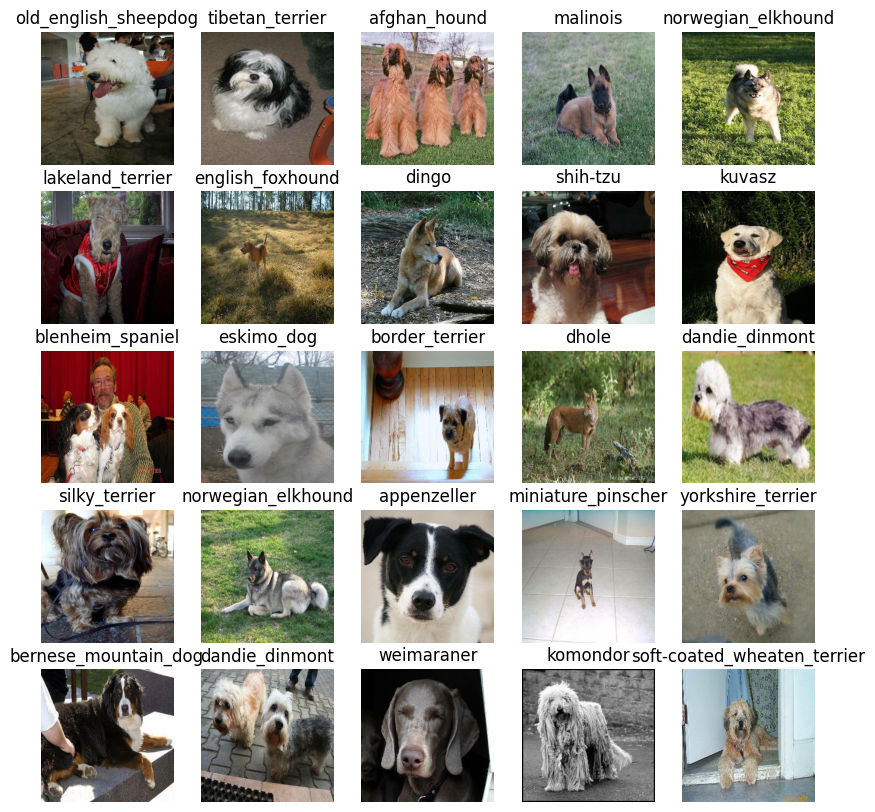

In [37]:
show_25_images(*train_data.as_numpy_iterator().next(), unique_breeds=unique_breeds)

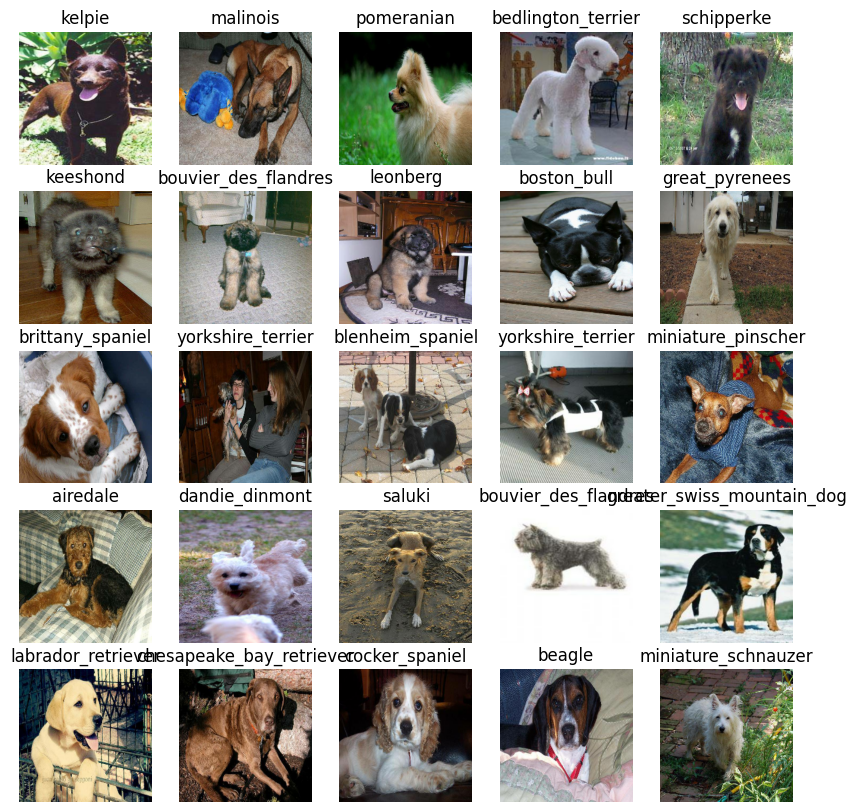

In [38]:
show_25_images(*val_data.as_numpy_iterator().next(), unique_breeds=unique_breeds)

For builfing a model, these are the standard practices: 

1. The input shape (our images in the form of Tensors) to our model
2. The output shape (image labels (y), in the form of Tensors) of our model
3. The URL of the model (we are not building from scratch) 

In [39]:
INPUT_SHAPE = IMAGE_SIZE + (3,)  # height, width, color channels
OUTPUT_SHAPE = len(unique_breeds)  # number of unique dog breeds (120)
MODEL_URL = "https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/140-224-feature-vector/2"


In [40]:
len(unique_breeds)

120

From here, we can use the above variables to build a model using transfer learning. So let's create a function that; 
1. Takes in the input shape, output shape and model URL
2. Defines the layers in Keras model in sequential fashion 
3. Compiles the model
4. Builds and Returns the model 

In [45]:
def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE, model_url=MODEL_URL):
    print("Building model with:", model_url)
    
    model = tf.keras.Sequential([
        hub.KerasLayer(model_url, 
                       trainable=False,
                       input_shape=input_shape),  # (224, 224, 3)
        tf.keras.layers.Dense(units=output_shape, 
                              activation="softmax")
    ])
    
    model.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(),
        metrics=["accuracy"]
    )
    
    return model


In [46]:
model = create_model()
model.summary()

Building model with: https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/140-224-feature-vector/2


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_3 (KerasLayer)  (None, 1792)              4363712   
                                                                 
 dense_3 (Dense)             (None, 120)               215160    
                                                                 
Total params: 4578872 (17.47 MB)
Trainable params: 215160 (840.47 KB)
Non-trainable params: 4363712 (16.65 MB)
_________________________________________________________________
